In [1]:
import pandas as pd
import numpy as np
from ollama import chat
import ollama
import json
import torch
from torch.nn.functional import cosine_similarity

In [2]:
df = pd.read_json("../data/all_courses_data.json")
df = df[df["Education cycle"] == "Second-cycle"]
owners = filter(lambda x: x.startswith("MP") or x == "TRACKS", df.Owner.unique())
df = df[df.Owner.isin(owners)]

In [3]:
courses = ["SSY098", "DAT471", "DAT470", "DAT675", "MVE550", "TDA507", "DAT695", "TMA947", "DAT341", "TDA233", "DAT475", "TIF360", "BBT046"]
subset = df[df["Course code"].isin(courses)]

In [4]:
subset = df[df["Course code"].isin(courses)]

In [5]:
df = df.reset_index(drop=True)

In [6]:
for column in df.columns:
    df = df.rename(columns={column: column.replace(" ", "_").lower()})

In [7]:
for i, idx in enumerate(np.arange(len(df)).reshape(-1, len(df) // 16)):
    df.iloc[idx].to_csv(f"../data/splits/split_{i}.csv")

In [8]:
def get_sps(course_rounds):
    sps = []
    for round in course_rounds:
        sps.extend(round["Study Periods"])
    return [int(sp[-1]) for sp in sps]

subset["SP"] = subset["Course Rounds"].apply(get_sps)

In [9]:
for column in subset.columns:
    subset = subset.rename(columns={column: column.replace(" ", "_").lower()})    

In [10]:
def get_metadata(row):
    metadata = {
        "course_code": row.course_code,
        "course_name": row.course_name,
        "owner": row.owner,
        "field_of_study": [field.strip() for field in row.main_field_of_study.split(",")],
        "periods": get_sps(row.course_rounds)
    }
    return metadata

metadatas = []
for course in subset.itertuples():
    metadatas.append(get_metadata(course))

In [11]:
# ID: Code ID
# metadata:
#   Course Code
#   Course Name
#   Owner
#   Main field of study
#   Study Periods

This course introduces students to recent developments and state-of-the-art methods in machine learning using artificial neural networks. This advanced course builds on Machine learning with neural networks (FFR135) and provides an in-depth analysis of many of the concepts and algorithms that were briefly introduced in that course, with particular emphasis on applications in the natural and engineering sciences. The goal is to become familiar with several advanced machine-learning methods, and to code them efficiently in Python using current neural-network packages. An essential part of the course are projects in deep learning and reinforcement learning.

Knowledge and understanding - Describe the different available neural network models with their advantages and disadvantages - Find relevant literature to keep up with this quickly advancing field Skills and ability - Implement a broad range of state-of-the-art neural network models - Train and validate these models - Optimize these models for a specific task - Plan, manage and execute a small scale project in the field - Write a report of their results of the project Judgement and approach - Critically analyse the advantages and disadvantages of the available neural network models - Benchmark the results of a neural network models against other models - Critically evaluate and discuss advances in the field of neural networks

This course is project based and focus on state-of-the-art applications of neural networks which are of relevance to research and industry. Focus: - Which model should be employed for a given task? - How should models be benchmarked? - What are the tradeoffs between complexity, accuracy and risk of overtraining in practical settings? - How does one evaluate the quality of the predictions made by the model?


In [15]:
subset = df[df["course_code"].isin(["DAT410"])]
for row in subset.itertuples():
    prompt = f"You are an assistant. Summarise the course to a short summary of at most 500 words (not a strict condition) and only mention things about the course, do not inlcude any unnecessary information. Do not output the number of words. This summary will then be used for retrieval and semantic search: \n\nAIM:\n{row.aim}\n\nLEARNING_OUTCOMES:\n\n{row.learning_outcomes}\n\nCONTENT:\n\n{row.content}"
    response = chat(
        model='qwen3:4b',
        messages=[{'role': 'user', 'content': prompt}],
        format='json',
        stream=False,
    )
    dai_summary = json.loads(response.message.content)["summary"]

In [39]:
summaries = pd.read_csv("../data/summaries/summaries_0.csv")

In [40]:
summaries_list = summaries.summary.values.tolist()
summaries_list.append(dai_summary)

In [ ]:
embeds = ollama.embed(
  model='qwen3-embedding:8b',
  input=summaries_list
)

In [19]:
embeds = np.array(embeds["embeddings"])
embeds = torch.from_numpy(embeds)

In [20]:
sim_matrix = torch.mm(embeds, embeds.t())

In [35]:
summaries["sim_to_dai"] = (1 - sim_matrix).round(decimals=3)[-1][:-1].tolist()

In [37]:
summaries[["course_name", "sim_to_dai"]]

,course_name,sim_to_dai
0,Advanced databases,0.534
1,Advanced machine learning with neural networks,0.475
2,Algorithms for machine learning and inference,0.341
3,Applied bioinformatics,0.621
4,Applied machine learning,0.307
5,Artificial intelligence for molecules,0.394
6,Computational methods in bioinformatics,0.559
7,Computational techniques for large-scale data,0.537
8,Image analysis,0.492
9,Nonlinear optimisation,0.560


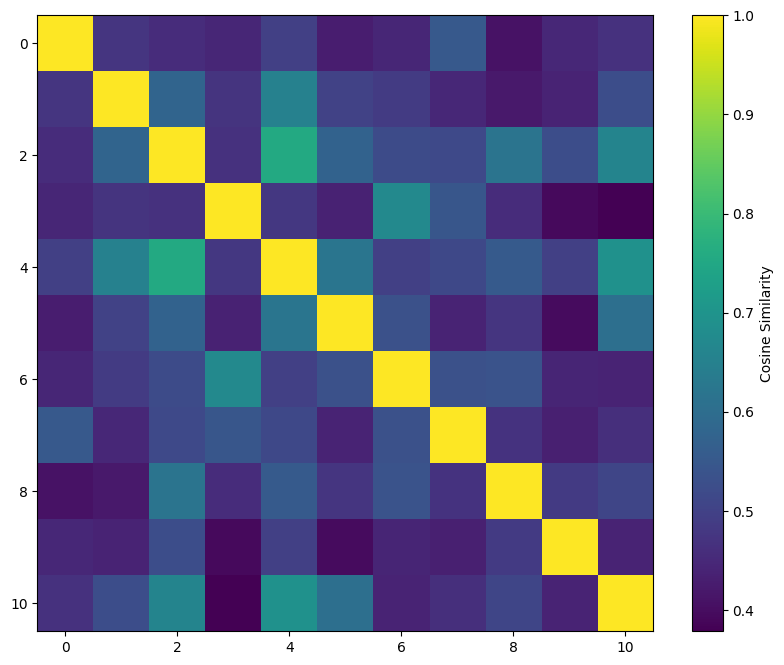

In [22]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 8))
plt.imshow(sim_matrix, cmap='viridis', interpolation='nearest')
plt.colorbar(label='Cosine Similarity')

In [ ]:
import textwrap

def wrap_text(text, width=128):
    if not isinstance(text, str):
        return str(text)
    return textwrap.fill(text, width)

for row in pd.read_csv("summaries_short.csv").itertuples():
    print(f"Course: {row.course_name}")
    print(wrap_text(row.summary)) 
    print()